In [80]:
import numpy as np
import matplotlib.pyplot as plt
from mpdaf.obj import Cube
from astropy.coordinates import SkyCoord
import sys
import os
import plotfancy as pf
from matplotlib.patches import Circle
from astropy.visualization import ZScaleInterval
from astropy.table import Table
from types import SimpleNamespace
import re
from astropy.io import ascii, fits
from astropy import units as u
from astropy.constants import c as speedoflight
from astropy.table import Table, vstack, hstack
from scipy.optimize import curve_fit
from astropy.cosmology import Planck18 as cosmo
from astropy import coordinates as coords
from astroquery.sdss import SDSS
from requests.exceptions import ConnectionError
from matplotlib.lines import Line2D
# from hst_phot import *
from prospect.models.templates import TemplateLibrary
from prospect.models import SpecModel
import prospect.fitting as fitting
from prospect.io import write_results as writer
import prospect.io.read_results as reader
from prospect.sources import CSPSpecBasis
from prospect.models import priors


# from calculate_jiang19_metallicity import calculate_metallicity_jiang19 as cjm19
sys.path.append('../../../')
import src.ifu_tools.line_ratios as lr
import src.ifu_tools.ifutools as ift

import logging 
logging.getLogger('mpdaf').setLevel(logging.WARNING)

import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)

pf.housestyle_rcparams()
lines_of_interest = {
'oiii5007': 5006.84,
'oiii4959': 4958.91,
'oii3726':  3726.03,
'halpha':   6562.80,
'hbeta':    4861.33,
'hgamma':   4340.46,
'hdelta':   4101.73,
'oiii4363': 4363.21,
}
rest_lambdas = {
# --- Primary [OIII] and [OII] ---
'oiii5007': 5006.84,
'oiii4959': 4958.91,
'oii3726':  3726.03,
'oii3729':  3728.82,

# --- Hydrogen Balmer Series ---
'halpha':   6562.80,
'hbeta':    4861.33,
'hgamma':   4340.46,
'hdelta':   4101.73,
'hepsilon': 3970.08,
'hzeta':    3889.06,
'heta':     3835.40,

# --- Key Diagnostic Lines ---
'oiii4363': 4363.21,
'neiii':    3868.75,

# --- Low-Ionization Lines ---
'nii6583':  6583.45,
'nii6548':  6548.05,
'sii6716':  6716.44,
'sii6731':  6730.82,

# --- Helium Lines ---
'heii4686': 4685.68,
'hei5876':  5875.62,
}
balmer_lambda = {
# 'halpha':   6562.80,
'hbeta':    4861.33,
'hgamma':   4340.46,
'hdelta':   4101.73,
'hepsilon': 3970.08,
'hzeta':    3889.06,
'heta':     3835.40,
}
lambda_keys = {
# --- Primary [OIII] and [OII] ---
'oiii5007': r'[OIII] $\lambda$5007',
'oiii4959': r'[OIII] $\lambda$4959',
'oii3726':  r'[OII] $\lambda$3726',
'oii3729':  r'[OII] $\lambda$3729',

# --- Hydrogen Balmer Series ---
'halpha':   r'H$\alpha$',
'hbeta':    r'H$\beta$',
'hgamma':   r'H$\gamma$',
'hdelta':   r'H$\delta$',
'hepsilon': r'H$\epsilon$',
'hzeta':    r'H$\zeta$',
'heta':     r'H$\eta$',

# --- Key Diagnostic Lines ---
'oiii4363': r'[OIII] $\lambda$4363',  # Auroral line
'neiii':    r'[NeIII] $\lambda$3869',

# --- Low-Ionization Lines ---
'nii6583':  r'[NII] $\lambda$6583',
'nii6548':  r'[NII] $\lambda$6548',
'sii6716':  r'[SII] $\lambda$6716',
'sii6731':  r'[SII] $\lambda$6731',

# --- Helium Lines (not forbidden) ---
'heii4686': r'HeII $\lambda$4686',
'hei5876':  r'HeI $\lambda$5876',
}

test = ascii.read('allsources.csv')
tab = test[test['object_id']!= 'STACK']

(array([ 0.,  0.,  0.,  3.,  2.,  2.,  9., 14., 37., 49., 18., 13.,  7.,
         3.]),
 array([0.        , 0.35714286, 0.71428571, 1.07142857, 1.42857143,
        1.78571429, 2.14285714, 2.5       , 2.85714286, 3.21428571,
        3.57142857, 3.92857143, 4.28571429, 4.64285714, 5.        ]),
 <BarContainer object of 14 artists>)

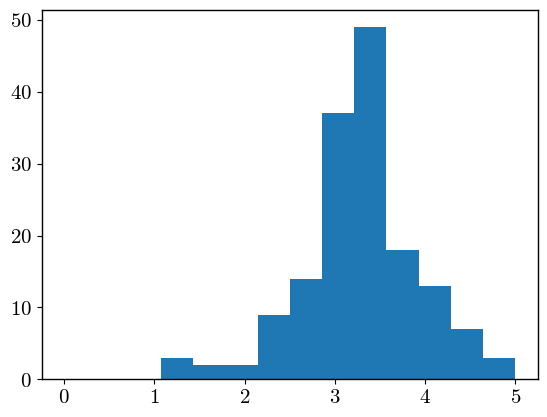

In [2]:
plt.hist(tab['oiii5007_flux']/tab['oiii4959_flux'], bins=np.linspace(0,5,15))

In [3]:
ratio = tab['oiii5007_flux']/tab['oiii4959_flux']
mask = np.isfinite(ratio)
np.median(ratio[mask])

np.float64(3.3433693754487015)

In [4]:
SNR_mask = ((tab['oiii5007_flux']/tab['oiii5007_flux_err'])>5)&((tab['oiii4959_flux']/tab['oiii4959_flux_err'])>5)
EW_mask = (tab['oiii5007_ew']>100)|(tab['hbeta_ew']>50)
selection = tab[SNR_mask&EW_mask]

In [5]:
selection

object_id,ra,dec,z,angdisp,foreground,cluster_member,lensed,Z_dir,Z_dir_e,Z_j19,Z_j19_e,R23,R23_e,mean_vel_disp,sterr_vel_disp,zcluster,name,oiii5007_flux,oiii5007_flux_err,oiii5007_ew,oiii5007_ew_err,oiii5007_centroid,oiii5007_fwhm,oiii5007_vel_disp,oiii4959_flux,oiii4959_flux_err,oiii4959_ew,oiii4959_ew_err,oiii4959_centroid,oiii4959_fwhm,oiii4959_vel_disp,oii3726_flux,oii3726_flux_err,oii3726_ew,oii3726_ew_err,oii3726_centroid,oii3726_fwhm,oii3726_vel_disp,oii3729_flux,oii3729_flux_err,oii3729_ew,oii3729_ew_err,oii3729_centroid,oii3729_fwhm,oii3729_vel_disp,halpha_flux,halpha_flux_err,halpha_ew,halpha_ew_err,halpha_centroid,halpha_fwhm,halpha_vel_disp,hbeta_flux,hbeta_flux_err,hbeta_ew,hbeta_ew_err,hbeta_centroid,hbeta_fwhm,hbeta_vel_disp,hgamma_flux,hgamma_flux_err,hgamma_ew,hgamma_ew_err,hgamma_centroid,hgamma_fwhm,hgamma_vel_disp,hdelta_flux,hdelta_flux_err,hdelta_ew,hdelta_ew_err,hdelta_centroid,hdelta_fwhm,hdelta_vel_disp,hepsilon_flux,hepsilon_flux_err,hepsilon_ew,hepsilon_ew_err,hepsilon_centroid,hepsilon_fwhm,hepsilon_vel_disp,hzeta_flux,hzeta_flux_err,hzeta_ew,hzeta_ew_err,hzeta_centroid,hzeta_fwhm,hzeta_vel_disp,heta_flux,heta_flux_err,heta_ew,heta_ew_err,heta_centroid,heta_fwhm,heta_vel_disp,oiii4363_flux,oiii4363_flux_err,oiii4363_ew,oiii4363_ew_err,oiii4363_centroid,oiii4363_fwhm,oiii4363_vel_disp,neiii_flux,neiii_flux_err,neiii_ew,neiii_ew_err,neiii_centroid,neiii_fwhm,neiii_vel_disp,nii6583_flux,nii6583_flux_err,nii6583_ew,nii6583_ew_err,nii6583_centroid,nii6583_fwhm,nii6583_vel_disp,nii6548_flux,nii6548_flux_err,nii6548_ew,nii6548_ew_err,nii6548_centroid,nii6548_fwhm,nii6548_vel_disp,sii6716_flux,sii6716_flux_err,sii6716_ew,sii6716_ew_err,sii6716_centroid,sii6716_fwhm,sii6716_vel_disp,sii6731_flux,sii6731_flux_err,sii6731_ew,sii6731_ew_err,sii6731_centroid,sii6731_fwhm,sii6731_vel_disp,heii4686_flux,heii4686_flux_err,heii4686_ew,heii4686_ew_err,heii4686_centroid,heii4686_fwhm,heii4686_vel_disp,hei5876_flux,hei5876_flux_err,hei5876_ew,hei5876_ew_err,hei5876_centroid,hei5876_fwhm,hei5876_vel_disp
str29,float64,float64,float64,float64,int64,int64,int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,str12,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64
38d05m01pt605s-44d20m27pt16s,38.08377916666666,-44.34087777777778,0.20850398292901562,19.3108421028434,1,0,0,9.285448803927414,0.05659444967265145,nan,nan,4.562448108492161,0.18142748904729583,68.80059323215505,17.964798000821027,0.282,rxj0232m44,40925.353055070475,713.3367134115044,119.83157456301223,5.705059708947216,5006.839379458619,2.5157799115966744,61.44322861986223,12894.932846442336,1853.6646968710384,21.343318197791106,8.512590400463738,4958.9777774400845,2.268575320848984,55.39919802788287,0.0,0.0,nan,nan,3726.03,1.0,24.400668213494743,0.0,0.0,nan,nan,3728.82,1.0,24.382410999599827,26979.13459314359,192.62347564093636,300.1046400915456,4.104142326262138,6562.735248383178,2.8184398606266465,52.96109372536083,11796.361212599046,174.72

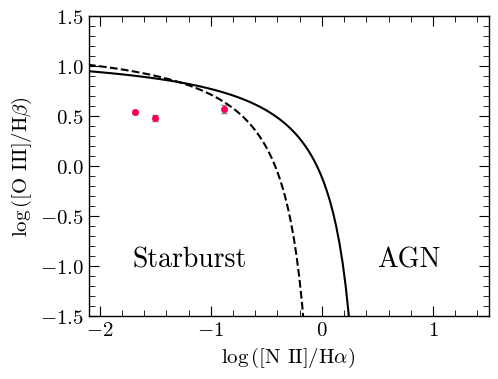

In [6]:
fig, ax = pf.create_plot()

ax.set_xlabel(r'$\log$([N II]/H$\alpha$)')
ax.set_ylabel(r'$\log$([O III]/H$\beta$)')

xvals = np.log10(selection['nii6583_flux']/selection['halpha_flux'])
yvals = np.log10(selection['oiii5007_flux']/selection['hbeta_flux'])

xerr = np.abs(xvals*np.sqrt( (selection['nii6583_flux_err']/selection['nii6583_flux'])**2 + (selection['halpha_flux_err']/selection['halpha_flux'])**2 ))
yerr = np.abs(yvals*np.sqrt( (selection['oiii5007_flux_err']/selection['oiii5007_flux'])**2 + (selection['hbeta_flux_err']/selection['hbeta_flux'])**2 ))

classf = lr.classify_bpt(xvals,yvals)
markers = ['o','x','^']
colors = ['#ff004f', "#77aca2", "#0359c3"]


for i,key in enumerate(list(classf.keys())):
    mask = classf.get(key)
    ax.errorbar(xvals[mask],yvals[mask], fmt=markers[i], yerr=yerr[mask], color=colors[i], ms=4, ecolor='gray', capsize=2)
ax.set_xlim(-2.1,1.5)
ax.set_ylim(-1.5,1.5)

grid = np.linspace(-2.5,0, 100)
grid2 = np.linspace(-2.5,.3, 100)

ax.plot(grid,lr.kauffmann03(grid),color='k', ls='--')
ax.plot(grid2,lr.kewley01(grid2),color='k')

ax.text(-1.7,-1,'Starburst', fontsize=20)
ax.text(0.5,-1,'AGN', fontsize=20)

pf.fix_plot([ax])
fig.savefig(f'figs/bpt.png', dpi=600, bbox_inches='tight')

In [7]:
Table(selection[0]).write('peas_test.csv', overwrite=True)

In [8]:
selection[0]

object_id,ra,dec,z,angdisp,foreground,cluster_member,lensed,Z_dir,Z_dir_e,Z_j19,Z_j19_e,R23,R23_e,mean_vel_disp,sterr_vel_disp,zcluster,name,oiii5007_flux,oiii5007_flux_err,oiii5007_ew,oiii5007_ew_err,oiii5007_centroid,oiii5007_fwhm,oiii5007_vel_disp,oiii4959_flux,oiii4959_flux_err,oiii4959_ew,oiii4959_ew_err,oiii4959_centroid,oiii4959_fwhm,oiii4959_vel_disp,oii3726_flux,oii3726_flux_err,oii3726_ew,oii3726_ew_err,oii3726_centroid,oii3726_fwhm,oii3726_vel_disp,oii3729_flux,oii3729_flux_err,oii3729_ew,oii3729_ew_err,oii3729_centroid,oii3729_fwhm,oii3729_vel_disp,halpha_flux,halpha_flux_err,halpha_ew,halpha_ew_err,halpha_centroid,halpha_fwhm,halpha_vel_disp,hbeta_flux,hbeta_flux_err,hbeta_ew,hbeta_ew_err,hbeta_centroid,hbeta_fwhm,hbeta_vel_disp,hgamma_flux,hgamma_flux_err,hgamma_ew,hgamma_ew_err,hgamma_centroid,hgamma_fwhm,hgamma_vel_disp,hdelta_flux,hdelta_flux_err,hdelta_ew,hdelta_ew_err,hdelta_centroid,hdelta_fwhm,hdelta_vel_disp,hepsilon_flux,hepsilon_flux_err,hepsilon_ew,hepsilon_ew_err,hepsilon_centroid,hepsilon_fwhm,hepsilon_vel_disp,hzeta_flux,hzeta_flux_err,hzeta_ew,hzeta_ew_err,hzeta_centroid,hzeta_fwhm,hzeta_vel_disp,heta_flux,heta_flux_err,heta_ew,heta_ew_err,heta_centroid,heta_fwhm,heta_vel_disp,oiii4363_flux,oiii4363_flux_err,oiii4363_ew,oiii4363_ew_err,oiii4363_centroid,oiii4363_fwhm,oiii4363_vel_disp,neiii_flux,neiii_flux_err,neiii_ew,neiii_ew_err,neiii_centroid,neiii_fwhm,neiii_vel_disp,nii6583_flux,nii6583_flux_err,nii6583_ew,nii6583_ew_err,nii6583_centroid,nii6583_fwhm,nii6583_vel_disp,nii6548_flux,nii6548_flux_err,nii6548_ew,nii6548_ew_err,nii6548_centroid,nii6548_fwhm,nii6548_vel_disp,sii6716_flux,sii6716_flux_err,sii6716_ew,sii6716_ew_err,sii6716_centroid,sii6716_fwhm,sii6716_vel_disp,sii6731_flux,sii6731_flux_err,sii6731_ew,sii6731_ew_err,sii6731_centroid,sii6731_fwhm,sii6731_vel_disp,heii4686_flux,heii4686_flux_err,heii4686_ew,heii4686_ew_err,heii4686_centroid,heii4686_fwhm,heii4686_vel_disp,hei5876_flux,hei5876_flux_err,hei5876_ew,hei5876_ew_err,hei5876_centroid,hei5876_fwhm,hei5876_vel_disp
str29,float64,float64,float64,float64,int64,int64,int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,str12,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64
38d05m01pt605s-44d20m27pt16s,38.08377916666666,-44.34087777777778,0.20850398292901562,19.3108421028434,1,0,0,9.285448803927414,0.05659444967265145,nan,nan,4.562448108492161,0.18142748904729583,68.80059323215505,17.964798000821027,0.282,rxj0232m44,40925.353055070475,713.3367134115044,119.83157456301223,5.705059708947216,5006.839379458619,2.5157799115966744,61.44322861986223,12894.932846442336,1853.6646968710384,21.343318197791106,8.512590400463738,4958.9777774400845,2.268575320848984,55.39919802788287,0.0,0.0,nan,nan,3726.03,1.0,24.400668213494743,0.0,0.0,nan,nan,3728.82,1.0,24.382410999599827,26979.13459314359,192.62347564093636,300.1046400915456,4.104142326262138,6562.735248383178,2.8184398606266465,52.96109372536083,11796.361212599046,174.72

In [9]:
selection[np.argmax(selection['oiii5007_ew'])]

object_id,ra,dec,z,angdisp,foreground,cluster_member,lensed,Z_dir,Z_dir_e,Z_j19,Z_j19_e,R23,R23_e,mean_vel_disp,sterr_vel_disp,zcluster,name,oiii5007_flux,oiii5007_flux_err,oiii5007_ew,oiii5007_ew_err,oiii5007_centroid,oiii5007_fwhm,oiii5007_vel_disp,oiii4959_flux,oiii4959_flux_err,oiii4959_ew,oiii4959_ew_err,oiii4959_centroid,oiii4959_fwhm,oiii4959_vel_disp,oii3726_flux,oii3726_flux_err,oii3726_ew,oii3726_ew_err,oii3726_centroid,oii3726_fwhm,oii3726_vel_disp,oii3729_flux,oii3729_flux_err,oii3729_ew,oii3729_ew_err,oii3729_centroid,oii3729_fwhm,oii3729_vel_disp,halpha_flux,halpha_flux_err,halpha_ew,halpha_ew_err,halpha_centroid,halpha_fwhm,halpha_vel_disp,hbeta_flux,hbeta_flux_err,hbeta_ew,hbeta_ew_err,hbeta_centroid,hbeta_fwhm,hbeta_vel_disp,hgamma_flux,hgamma_flux_err,hgamma_ew,hgamma_ew_err,hgamma_centroid,hgamma_fwhm,hgamma_vel_disp,hdelta_flux,hdelta_flux_err,hdelta_ew,hdelta_ew_err,hdelta_centroid,hdelta_fwhm,hdelta_vel_disp,hepsilon_flux,hepsilon_flux_err,hepsilon_ew,hepsilon_ew_err,hepsilon_centroid,hepsilon_fwhm,hepsilon_vel_disp,hzeta_flux,hzeta_flux_err,hzeta_ew,hzeta_ew_err,hzeta_centroid,hzeta_fwhm,hzeta_vel_disp,heta_flux,heta_flux_err,heta_ew,heta_ew_err,heta_centroid,heta_fwhm,heta_vel_disp,oiii4363_flux,oiii4363_flux_err,oiii4363_ew,oiii4363_ew_err,oiii4363_centroid,oiii4363_fwhm,oiii4363_vel_disp,neiii_flux,neiii_flux_err,neiii_ew,neiii_ew_err,neiii_centroid,neiii_fwhm,neiii_vel_disp,nii6583_flux,nii6583_flux_err,nii6583_ew,nii6583_ew_err,nii6583_centroid,nii6583_fwhm,nii6583_vel_disp,nii6548_flux,nii6548_flux_err,nii6548_ew,nii6548_ew_err,nii6548_centroid,nii6548_fwhm,nii6548_vel_disp,sii6716_flux,sii6716_flux_err,sii6716_ew,sii6716_ew_err,sii6716_centroid,sii6716_fwhm,sii6716_vel_disp,sii6731_flux,sii6731_flux_err,sii6731_ew,sii6731_ew_err,sii6731_centroid,sii6731_fwhm,sii6731_vel_disp,heii4686_flux,heii4686_flux_err,heii4686_ew,heii4686_ew_err,heii4686_centroid,heii4686_fwhm,heii4686_vel_disp,hei5876_flux,hei5876_flux_err,hei5876_ew,hei5876_ew_err,hei5876_centroid,hei5876_fwhm,hei5876_vel_disp
str29,float64,float64,float64,float64,int64,int64,int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,str12,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64
4d46m35pt34s-20d26m04pt362s,4.776483333333333,-20.434545,0.5281643173109969,33.71796440119023,0,0,0,nan,nan,9.127627555086473,0.001353397172330448,5.649086981654453,0.3040330069783813,49.040615570484825,12.796590573888835,0.277,s26,6228.778788338162,125.74057611634852,7201.58220092841,397.0880821684763,5006.842189217474,1.8072016208162445,42.36500403453211,1913.2298940587884,246.26683275814784,29.77024844148575,10.632162576843369,4958.889660661423,1.5720692222085526,36.13790830715717,519.5547382476107,69.42891045430139,22.599612508345185,15.20375418087949,3726.8932408166543,0.9954335156241744,24.18170367425463,521.4307065079821,69.7206795456017,22.71120063428617,15.267646664755185,3728.786784119692,0.9954335156241744,24.163610295316744,0.0,0.0

In [10]:
selection.sort('oiii5007_flux')

In [11]:
selection

object_id,ra,dec,z,angdisp,foreground,cluster_member,lensed,Z_dir,Z_dir_e,Z_j19,Z_j19_e,R23,R23_e,mean_vel_disp,sterr_vel_disp,zcluster,name,oiii5007_flux,oiii5007_flux_err,oiii5007_ew,oiii5007_ew_err,oiii5007_centroid,oiii5007_fwhm,oiii5007_vel_disp,oiii4959_flux,oiii4959_flux_err,oiii4959_ew,oiii4959_ew_err,oiii4959_centroid,oiii4959_fwhm,oiii4959_vel_disp,oii3726_flux,oii3726_flux_err,oii3726_ew,oii3726_ew_err,oii3726_centroid,oii3726_fwhm,oii3726_vel_disp,oii3729_flux,oii3729_flux_err,oii3729_ew,oii3729_ew_err,oii3729_centroid,oii3729_fwhm,oii3729_vel_disp,halpha_flux,halpha_flux_err,halpha_ew,halpha_ew_err,halpha_centroid,halpha_fwhm,halpha_vel_disp,hbeta_flux,hbeta_flux_err,hbeta_ew,hbeta_ew_err,hbeta_centroid,hbeta_fwhm,hbeta_vel_disp,hgamma_flux,hgamma_flux_err,hgamma_ew,hgamma_ew_err,hgamma_centroid,hgamma_fwhm,hgamma_vel_disp,hdelta_flux,hdelta_flux_err,hdelta_ew,hdelta_ew_err,hdelta_centroid,hdelta_fwhm,hdelta_vel_disp,hepsilon_flux,hepsilon_flux_err,hepsilon_ew,hepsilon_ew_err,hepsilon_centroid,hepsilon_fwhm,hepsilon_vel_disp,hzeta_flux,hzeta_flux_err,hzeta_ew,hzeta_ew_err,hzeta_centroid,hzeta_fwhm,hzeta_vel_disp,heta_flux,heta_flux_err,heta_ew,heta_ew_err,heta_centroid,heta_fwhm,heta_vel_disp,oiii4363_flux,oiii4363_flux_err,oiii4363_ew,oiii4363_ew_err,oiii4363_centroid,oiii4363_fwhm,oiii4363_vel_disp,neiii_flux,neiii_flux_err,neiii_ew,neiii_ew_err,neiii_centroid,neiii_fwhm,neiii_vel_disp,nii6583_flux,nii6583_flux_err,nii6583_ew,nii6583_ew_err,nii6583_centroid,nii6583_fwhm,nii6583_vel_disp,nii6548_flux,nii6548_flux_err,nii6548_ew,nii6548_ew_err,nii6548_centroid,nii6548_fwhm,nii6548_vel_disp,sii6716_flux,sii6716_flux_err,sii6716_ew,sii6716_ew_err,sii6716_centroid,sii6716_fwhm,sii6716_vel_disp,sii6731_flux,sii6731_flux_err,sii6731_ew,sii6731_ew_err,sii6731_centroid,sii6731_fwhm,sii6731_vel_disp,heii4686_flux,heii4686_flux_err,heii4686_ew,heii4686_ew_err,heii4686_centroid,heii4686_fwhm,heii4686_vel_disp,hei5876_flux,hei5876_flux_err,hei5876_ew,hei5876_ew_err,hei5876_centroid,hei5876_fwhm,hei5876_vel_disp
str29,float64,float64,float64,float64,int64,int64,int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,str12,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64
8d37m02pt79s2d24m57pt689s,8.617441666666666,2.416024722222222,0.5133134583394461,32.79382826391661,0,0,0,nan,nan,8.021302428493389,0.0031076903268883464,7.104372224276769,0.6858963970434612,55.00161327586024,13.712465380921362,0.388,macs0034p02a,1052.5139050743378,68.35888650935955,23.85661439265894,4.232223853891691,5006.7973657659295,1.472387938930396,32.93712583067687,797.846305029453,105.37678659874335,15.042744544164607,5.511990677949504,4959.200344149392,3.2688320595104683,81.97397029700586,1452.9104324573043,112.52555502740711,75.65800937072412,29.51831605834613,3725.9584959438557,1.5103119309747066,45.72666546021663,2181.8506807327344,143.41893364343912,113.82464867608545,37.62243528598357,3728.5816573871507,1.5103119309747066,45.69245

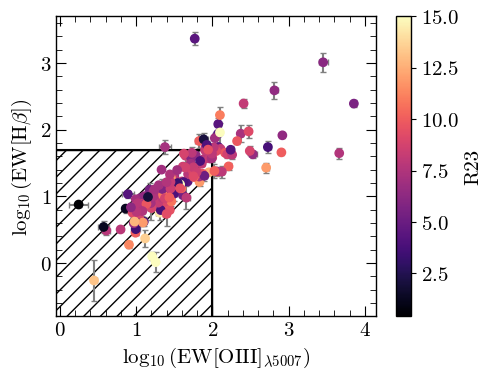

In [12]:
fig, ax = pf.create_plot()
err_x = 0.434*(tab['oiii5007_ew_err']/(tab['oiii5007_ew']))
err_y = 0.434*np.abs(tab['hbeta_ew_err']/(tab['hbeta_ew']))


ax.errorbar(np.log10(tab['oiii5007_ew']),np.log10(tab['hbeta_ew']), yerr= err_y, xerr=err_x, fmt='o', ecolor='gray', capsize=2, mfc='none', mec='none')
cbar = ax.scatter(np.log10(tab['oiii5007_ew']),np.log10(tab['hbeta_ew']), c=tab['R23'], zorder=10, cmap='magma', vmax=15)
plt.colorbar(cbar, label='R23')

ax.set_xlabel(r'$\log_{10}($EW[OIII]$_{\lambda5007}$)')
ax.set_ylabel(r'$\log_{10}($EW[H$\beta$])')

ax.set_xlim(-0.05, 4.15)
ax.set_ylim(-0.8, 3.7)

ax.vlines(2,-100,np.log10(50),color='k')
ax.hlines(np.log10(50),-100,2,color='k')
ax.fill_between([-100,2],-100,np.log10(50), facecolor='white', edgecolor='black', zorder=-10, hatch='//')

pf.fix_plot([ax])
fig.savefig(f'figs/populations.png', dpi=600, bbox_inches='tight')

In [13]:
grapes = tab[(tab['halpha_flux']>0)&(tab['oiii5007_ew']>100)]
grapes.sort('oiii5007_flux')
grapes[-2]

object_id,ra,dec,z,angdisp,foreground,cluster_member,lensed,Z_dir,Z_dir_e,Z_j19,Z_j19_e,R23,R23_e,mean_vel_disp,sterr_vel_disp,zcluster,name,oiii5007_flux,oiii5007_flux_err,oiii5007_ew,oiii5007_ew_err,oiii5007_centroid,oiii5007_fwhm,oiii5007_vel_disp,oiii4959_flux,oiii4959_flux_err,oiii4959_ew,oiii4959_ew_err,oiii4959_centroid,oiii4959_fwhm,oiii4959_vel_disp,oii3726_flux,oii3726_flux_err,oii3726_ew,oii3726_ew_err,oii3726_centroid,oii3726_fwhm,oii3726_vel_disp,oii3729_flux,oii3729_flux_err,oii3729_ew,oii3729_ew_err,oii3729_centroid,oii3729_fwhm,oii3729_vel_disp,halpha_flux,halpha_flux_err,halpha_ew,halpha_ew_err,halpha_centroid,halpha_fwhm,halpha_vel_disp,hbeta_flux,hbeta_flux_err,hbeta_ew,hbeta_ew_err,hbeta_centroid,hbeta_fwhm,hbeta_vel_disp,hgamma_flux,hgamma_flux_err,hgamma_ew,hgamma_ew_err,hgamma_centroid,hgamma_fwhm,hgamma_vel_disp,hdelta_flux,hdelta_flux_err,hdelta_ew,hdelta_ew_err,hdelta_centroid,hdelta_fwhm,hdelta_vel_disp,hepsilon_flux,hepsilon_flux_err,hepsilon_ew,hepsilon_ew_err,hepsilon_centroid,hepsilon_fwhm,hepsilon_vel_disp,hzeta_flux,hzeta_flux_err,hzeta_ew,hzeta_ew_err,hzeta_centroid,hzeta_fwhm,hzeta_vel_disp,heta_flux,heta_flux_err,heta_ew,heta_ew_err,heta_centroid,heta_fwhm,heta_vel_disp,oiii4363_flux,oiii4363_flux_err,oiii4363_ew,oiii4363_ew_err,oiii4363_centroid,oiii4363_fwhm,oiii4363_vel_disp,neiii_flux,neiii_flux_err,neiii_ew,neiii_ew_err,neiii_centroid,neiii_fwhm,neiii_vel_disp,nii6583_flux,nii6583_flux_err,nii6583_ew,nii6583_ew_err,nii6583_centroid,nii6583_fwhm,nii6583_vel_disp,nii6548_flux,nii6548_flux_err,nii6548_ew,nii6548_ew_err,nii6548_centroid,nii6548_fwhm,nii6548_vel_disp,sii6716_flux,sii6716_flux_err,sii6716_ew,sii6716_ew_err,sii6716_centroid,sii6716_fwhm,sii6716_vel_disp,sii6731_flux,sii6731_flux_err,sii6731_ew,sii6731_ew_err,sii6731_centroid,sii6731_fwhm,sii6731_vel_disp,heii4686_flux,heii4686_flux_err,heii4686_ew,heii4686_ew_err,heii4686_centroid,heii4686_fwhm,heii4686_vel_disp,hei5876_flux,hei5876_flux_err,hei5876_ew,hei5876_ew_err,hei5876_centroid,hei5876_fwhm,hei5876_vel_disp
str29,float64,float64,float64,float64,int64,int64,int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,str12,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64
38d04m12pt825s-44d21m10pt642s,38.070229166666664,-44.35295611111111,0.40292640529351553,66.73403958150307,0,0,0,8.969458542722732,0.0071141320617926825,8.150940159413311,0.0002622770955946467,8.162632124545151,0.2310792637281556,52.167125686054774,11.366223970474508,0.282,rxj0232m44,22567.1412073046,354.6168687556022,128.08897740369298,5.497713979981577,5006.834015829306,1.9980823399660776,47.58586696794032,6909.889981192684,933.7871419981336,19.408720732766298,7.277460935748094,4958.849131583009,1.7838306402540278,42.122918614158394,9815.98386042128,333.47237723449535,31.03228480758622,5.3098464551879445,3726.2293091856905,2.2526145560741524,73.15631758124707,11807.609335391948,374.7664395449063,37.404139444223546,5.967367573421555,3729.12559

In [14]:
candidate = grapes[-2]
cluster = candidate['name']
print(cluster)
loc = '../../../cubes/'+cluster+'_COMBINED_CUBE_MED_FINAL.fits'
with fits.open(loc) as hdul:
    cx,cy = (hdul[1].header['CRVAL1'],hdul[1].header['CRVAL2'])
    cent = SkyCoord(cx,cy, unit = u.deg)

galloc = SkyCoord(candidate['ra'], candidate['dec'], unit=u.deg)
cube_ift = ift.museCube(loc, cent.ra.deg,cent.dec.deg)
cluster = Cube(loc)
linefits = cube_ift.pick_target(galloc,candidate['z'],0.7,plot=False)

spectrum_o = cube_ift.spectra.get(list(cube_ift.spectra.keys())[0])
rest_spectrum = cube_ift.rest_spectra.get(list(cube_ift.spectra.keys())[0])

freq = np.linspace(rest_spectrum.get_start(), rest_spectrum.get_end(), rest_spectrum.shape[0])
redshift = cube_ift.ex_table['z'][0]

wave_rest = rest_spectrum.wave.coord()  # Angstroms
flux = rest_spectrum.data*1e-20            # erg/s/cm^2/Angstrom (check units)
flux_unc = np.sqrt(rest_spectrum.var*1e-20)   # Get std deviation from variance

rxj0232m44


True

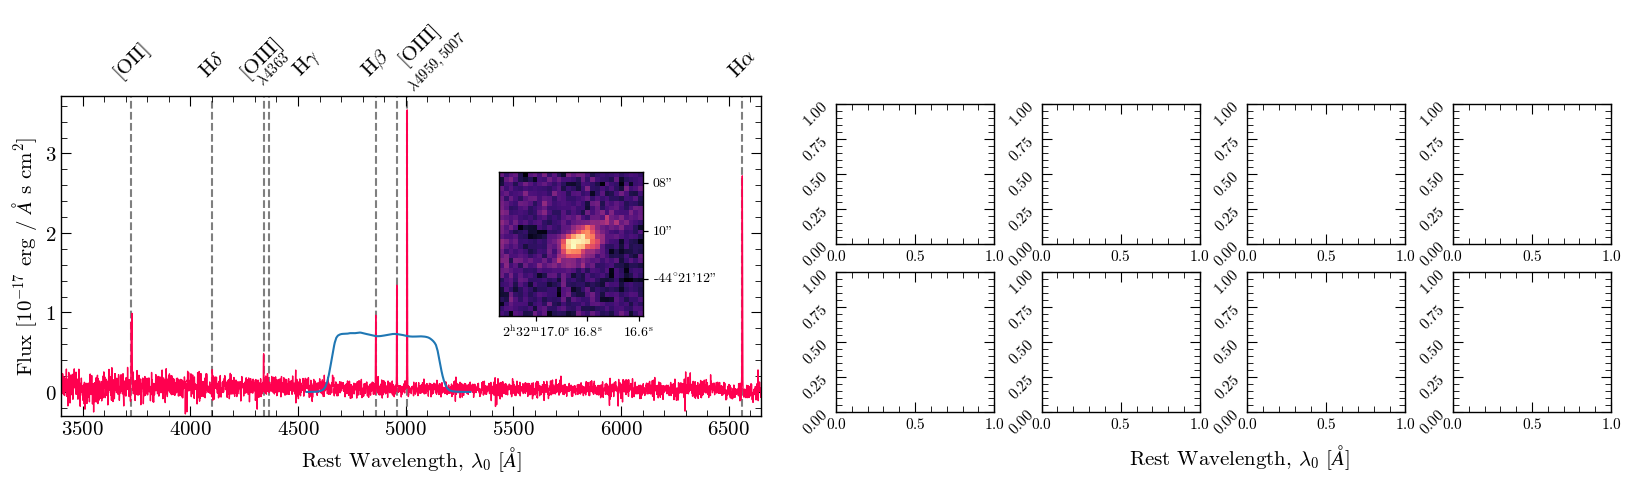

In [ ]:
fig, axes_grid = plt.subplots(2,4,
                              figsize=(10,4))
plt.subplots_adjust(hspace=0.2, wspace=0.3)

specax = fig.add_axes((-.65,.1,.7,.8))

ax_flat = axes_grid.flatten()
all_ax = np.append(ax_flat,specax)

specax.set_xlabel(r'Rest Wavelength, $\lambda_0$ [$\AA$]')
specax.set_ylabel(r'Flux $[10^{-17}$ erg / $\AA$ s cm$^2]$')
ax_flat[-3].set_xlabel(r'Rest Wavelength, $\lambda_0$ [$\AA$]')
ax_flat[-3].xaxis.set_label_coords(1.25,-.22)

for ax in ax_flat:
    ax.tick_params('y', rotation=45, labelsize=11)
    ax.tick_params('x', labelsize=11)

#### PLOT SPECTRUM ####

specax.plot(freq, rest_spectrum.data/1000, color='#ff004f', lw=1)

max_peak_y = np.max(rest_spectrum.data)/1000*1.05
specax.set_ylim(-.3,max_peak_y)
specax.set_xlim(3400,6650)

line_names = list(cube_ift.rest_lambdas.keys())

for l in list(lines_of_interest.keys()):
    wl = rest_lambdas.get(l)
    name = lambda_keys.get(l)
    # print(name)
    specax.vlines(wl, -10,10, linestyle = 'dashed', zorder=-10, color='k', alpha=0.5)
    fac = 1.05
    if ('oiii49' in l) or ('oiii5' in l):
        name = '[OIII]\n'+r'$_{\lambda4959,5007}$'
        wl += 100
        fac = 1
    if 'oiii4959' in l:
        name = ''
    if 'oii3' in l:
        name = '[OII]'
    if 'hgamma' in l:
        wl += 200
    if l == 'oiii4363':
        name  = '[OIII]\n'+r'$^{\lambda4363}$'
        fac = 1
    specax.text(wl, max_peak_y * fac, name, ha='center', va='bottom', rotation=45, fontsize=15)

##### PLOT PHOTOMETRY AND PASSBAND #####

gsubcube = cluster.subcube((galloc.dec.deg, galloc.ra.deg),6)
bandpass = ascii.read('HST_WFC3_UVIS2.F689M.dat', names=['lambda','bp'])
image = gsubcube.bandpass_image(bandpass['lambda'], bandpass['bp'])

photax = fig.add_axes((-0.23,0.35,0.18,0.36), projection=image.wcs.wcs)
photax.imshow(image.data, cmap='magma')
for i in range(2):
    photax.coords[i].set_ticks(number=3)
    photax.coords[i].set_ticklabel(size=10)
    photax.coords[i].set_ticks_position('br')
    photax.coords[i].set_axislabel('')
    photax.coords[i].tick_params(rotation=45)

photax.coords[1].set_separator((r'$^{\circ}$', "'", '"'))
photax.coords[0].set_separator((r'$^{\mathrm{h}}$', r'$^{\mathrm{m}}$',r'$^{\mathrm{s}}$'))

specax.plot(bandpass['lambda']/(1+redshift), (bandpass['bp']*3-.3)

pf.fix_plot(all_ax)
# pf.fix_plot([photax], tickdir='out')

In [150]:
dir(photax.coords[0])

['__class__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__firstlineno__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__sizeof__',
 '__static_attributes__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 '_auto_axislabel',
 '_axislabel_set',
 '_axislabels',
 '_clear_grid_contour',
 '_compute_ticks',
 '_coord_index',
 '_coord_scale_to_deg',
 '_coord_type',
 '_coord_unit',
 '_coord_wrap',
 '_custom_formatter',
 '_default_label',
 '_draw_axislabels',
 '_draw_grid',
 '_draw_ticks',
 '_fl_spacing',
 '_format_unit',
 '_formatter_locator',
 '_frame',
 '_get_default_axislabel',
 '_get_gridline',
 '_grid_lines',
 '_grid_lines_kwargs',
 '_lbl_world',
 '_lblinfo',
 '_minor_frequency',
 '_parent_axes',
 '_parent_map',
 '_ticklabels',
 '_ticks',
 '_transform',
 '_update_gr

[0.0]